# SPI/AI Preprocessing Notebook

Preprocessing only: load AOI boundaries, align rasters to a shared grid, clip land cover, DEM, and roads.
Outputs are written as GeoPackage and GeoTIFF files in the interim folder.

> **Note:** Use the `sds` kernel before running.

In [1]:
import re
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from rasterio import features
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import reproject
from scipy import ndimage

In [11]:
# --- paths ---
root = Path('/home/wasif/sds/sds/spi_gb_north')
raw        = root / 'data/raw'
interim    = root / 'data/interim'
processed  = root / 'data/processed'
metadata   = root / 'data/metadata'

for d in [interim, processed, metadata]:
    d.mkdir(parents=True, exist_ok=True)

CRS = 'EPSG:32643'
RES = 100.0

# Default class codes (can be auto-adjusted after reading merged raster).
FOREST_CODE, WATER_CODE = 1, 8
FOREST_CANDIDATES = [1, 10]
WATER_CANDIDATES = [8, 80]

# Non-strict SPI setting: use broader vegetation as the green component.
USE_NON_STRICT_SPI = True
SPI_VEG_CODES = [1, 2]  # trees + shrub/scrub in encoded raster

admin_path   = raw / 'admin_boundaries/geoBoundaries-PAK-ADM3.geojson'
dem_path     = raw / 'dem/dem.tif'
roads_path   = raw / 'roads/spi_gb_north.gpkg'
clip_path    = raw / 'roads/clipping_boundary.geojson'
lc_files     = sorted((raw / 'landcover').glob('*.tif'))
tehsil_list  = Path('/home/wasif/sds/sds/project/aoi_tehsils_list.txt')

AJK = ['BAGH','DHEERKOT','BARNALA','BHIMBER','SAMAHNI','HATTIAN BALA','HAVELI',
       'KOTLI','NAKIAL','SEHNSA','DUDYAL','MIRPUR','MUZAFFARABAD','ATHUMQAM',
       'ABBASPUR','HAJEERA','RAWALAKOT','PALLANDARI']

print('Landcover tiles:', [f.name for f in lc_files])
print('USE_NON_STRICT_SPI:', USE_NON_STRICT_SPI, '| SPI_VEG_CODES:', SPI_VEG_CODES)

Landcover tiles: ['landcover1.tif', 'landcover2.tif', 'landcover3.tif']
USE_NON_STRICT_SPI: True | SPI_VEG_CODES: [1, 2]


In [3]:
import rasterio
import numpy as np

with rasterio.open(lc_files[0]) as src:
    sample = src.read(1, window=((0, 2000), (0, 2000)))  # small chunk
    print(np.unique(sample))

[0]


In [4]:
# --- helper functions ---

def norm_name(s):
    s = s.upper().strip()
    s = re.sub(r'[^A-Z0-9]+', ' ', s.replace('`', ''))
    return s.strip()

def load_tehsil_names(path):
    if not path.exists():
        return set()
    names = set()
    for line in path.read_text().replace('\\n', '\n').splitlines():
        line = line.strip()
        if line and not line.lower().startswith('names of'):
            names.add(norm_name(line))
    return names

def make_grid(gdf):
    minx, miny, maxx, maxy = gdf.total_bounds
    w = int(np.ceil((maxx - minx) / RES))
    h = int(np.ceil((maxy - miny) / RES))
    return from_origin(minx, maxy, RES, RES), w, h

def reproject_to_grid(src_path, transform, w, h, resampling, nodata, band=1):
    with rasterio.open(src_path) as src:
        dst = np.full((h, w), nodata, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band),
            destination=dst,
            src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
            dst_transform=transform, dst_crs=CRS, dst_nodata=nodata,
            resampling=resampling,
        )
    return dst

def write_tif(path, arr, transform, w, h, nodata, dtype):
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, 'w', driver='GTiff', width=w, height=h,
                       count=1, dtype=dtype, crs=CRS, transform=transform,
                       nodata=nodata, compress='deflate') as dst:
        dst.write(arr.astype(dtype), 1)


## Step 1: Load AOI Boundaries

In [5]:
# load + filter tehsils
aoi_names = load_tehsil_names(tehsil_list) | {norm_name(x) for x in AJK}

all_t = gpd.read_file(admin_path)

# ensure CRS
if all_t.crs is None:
    all_t = all_t.set_crs('EPSG:4326')

# clean geometries
all_t['geometry'] = all_t.geometry.make_valid()
all_t = all_t[~all_t.geometry.is_empty].copy()

# normalize names
all_t['name_norm'] = all_t['shapeName'].map(norm_name)

# filter AOI
tehsils = all_t[all_t['name_norm'].isin(aoi_names)].copy()

# fallback: bbox intersection
if len(tehsils) < 20:
    print('too few matches, falling back to bbox')
    bbox = gpd.read_file(clip_path).to_crs('EPSG:4326')
    tehsils = all_t[all_t.intersects(bbox.geometry.union_all())].copy()

# project
tehsils = tehsils.to_crs(CRS)

aoi_geom = tehsils.union_all()

# create AOI GeoDataFrame
aoi = gpd.GeoDataFrame(
    {'name': ['aoi']},
    geometry=[aoi_geom],
    crs=CRS
)

# save outputs
tehsils.to_file(interim / 'tehsils_aoi_32643.gpkg', driver='GPKG')
aoi.to_file(interim / 'aoi_boundary_32643.gpkg', driver='GPKG')

print(f'Tehsils selected: {len(tehsils)}')

Tehsils selected: 81


## Step 2: Build Processing Grid

In [6]:
transform, W, H = make_grid(aoi)

aoi_geom = aoi.geometry.union_all()

region_mask = features.geometry_mask(
    [aoi_geom],
    out_shape=(H, W),
    transform=transform,
    invert=True
)

print(f'Grid: {H} x {W}')

Grid: 4801 x 6122


## Step 3: Land Cover Preprocessing

In [12]:
# merge all tiles
lc = np.zeros((H, W), dtype=np.uint8)
for f in lc_files:
    tile = reproject_to_grid(f, transform, W, H, Resampling.nearest, 0).astype(np.uint8)
    lc = np.where(tile > 0, tile, lc).astype(np.uint8)

lc_clipped = lc.copy()
lc_clipped[~region_mask] = 0

# Memory-safe class counts using bincount (no np.unique on masked copy).
counts = np.bincount(lc_clipped.ravel(), minlength=256)
inside_pixels = int(region_mask.sum())

# Auto-select strict forest/water code from candidate sets.
forest_counts = {c: int(counts[c]) for c in FOREST_CANDIDATES if c < len(counts)}
water_counts = {c: int(counts[c]) for c in WATER_CANDIDATES if c < len(counts)}
FOREST_CODE = max(forest_counts, key=forest_counts.get) if forest_counts else FOREST_CODE
WATER_CODE = max(water_counts, key=water_counts.get) if water_counts else WATER_CODE

# Strict masks (for audit/sensitivity comparison).
forest_mask_strict = (lc_clipped == FOREST_CODE).astype(np.uint8)
water_mask = (lc_clipped == WATER_CODE).astype(np.uint8)

# Non-strict vegetation proxy mask for SPI green component.
veg_mask = np.isin(lc_clipped, SPI_VEG_CODES).astype(np.uint8)

# Active green mask used by downstream SPI workflow.
if USE_NON_STRICT_SPI:
    forest_mask = veg_mask.copy()
    green_mode = f'non_strict_veg_proxy_codes={SPI_VEG_CODES}'
else:
    forest_mask = forest_mask_strict.copy()
    green_mode = f'strict_forest_code={FOREST_CODE}'

write_tif(interim/'landcover_2024_32643_100m.tif', lc_clipped, transform, W, H, 0, 'uint8')
write_tif(interim/'forest_mask_strict_32643_100m.tif', forest_mask_strict, transform, W, H, 0, 'uint8')
write_tif(interim/'veg_mask_32643_100m.tif', veg_mask, transform, W, H, 0, 'uint8')
write_tif(interim/'forest_mask_32643_100m.tif', forest_mask, transform, W, H, 0, 'uint8')
write_tif(interim/'water_mask_32643_100m.tif', water_mask, transform, W, H, 0, 'uint8')

print(f'Chosen FOREST_CODE(strict): {FOREST_CODE} (candidates={forest_counts})')
print(f'Chosen WATER_CODE        : {WATER_CODE} (candidates={water_counts})')
print(f'Active green mode for SPI: {green_mode}')
print(f'Inside AOI pixels        : {inside_pixels:,}')

Chosen FOREST_CODE(strict): 1 (candidates={1: 67345, 10: 54})
Chosen WATER_CODE        : 8 (candidates={8: 2988690, 80: 0})
Active green mode for SPI: non_strict_veg_proxy_codes=[1, 2]
Inside AOI pixels        : 12,619,101


In [13]:
# diagnostics: class distribution inside AOI (memory-safe)
counts = np.bincount(lc_clipped.ravel(), minlength=256)
inside_pixels = int(region_mask.sum())

print('Class distribution inside AOI (code: pct):')
nonzero_codes = np.where(counts > 0)[0]
for c in nonzero_codes:
    if c == 0:
        continue
    pct = (counts[c] / inside_pixels) * 100 if inside_pixels else 0
    if pct >= 0.01:
        print(f'  {int(c):>3}: {pct:7.3f}%')

strict_forest_pixels = int(counts[FOREST_CODE]) if FOREST_CODE < len(counts) else 0
water_pixels = int(counts[WATER_CODE]) if WATER_CODE < len(counts) else 0
veg_pixels = int(veg_mask.sum())
active_green_pixels = int(forest_mask.sum())

print()
print(f'Strict forest code: {FOREST_CODE}')
print(f'Water code        : {WATER_CODE}')
print(f'Strict forest pixels: {strict_forest_pixels:,} ({(strict_forest_pixels / inside_pixels) * 100:.3f}% of AOI)')
print(f'Vegetation proxy pixels: {veg_pixels:,} ({(veg_pixels / inside_pixels) * 100:.3f}% of AOI)')
print(f'Active SPI green pixels: {active_green_pixels:,} ({(active_green_pixels / inside_pixels) * 100:.3f}% of AOI)')
print(f'Water pixels: {water_pixels:,} ({(water_pixels / inside_pixels) * 100:.3f}% of AOI)')

Class distribution inside AOI (code: pct):
    1:   0.534%
    2:   8.129%
    5:   1.458%
    7:   4.538%
    8:  23.684%
    9:  16.972%
   11:  44.682%

Strict forest code: 1
Water code        : 8
Strict forest pixels: 67,345 (0.534% of AOI)
Vegetation proxy pixels: 1,093,118 (8.662% of AOI)
Active SPI green pixels: 1,093,118 (8.662% of AOI)
Water pixels: 2,988,690 (23.684% of AOI)


## Step 3A: Optional Vegetation Proxy Check (Trees + Shrubs)

Active non-strict vegetation codes: [1, 2]
Vegetation pixels: 1,093,118 (8.662% of AOI)


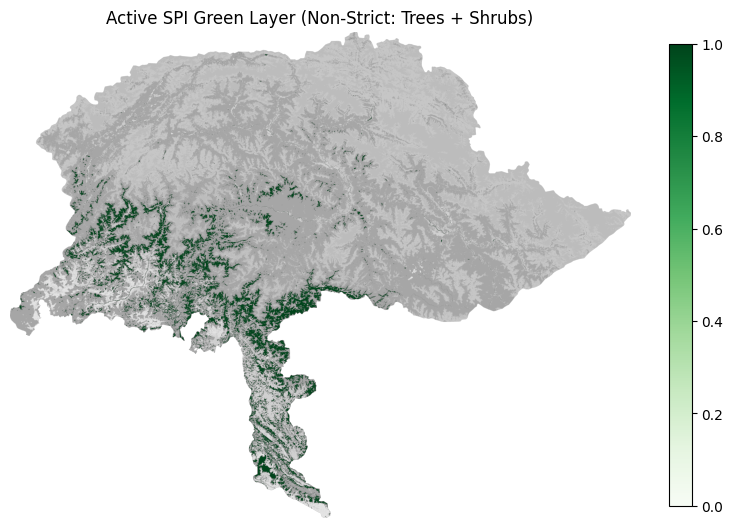

In [14]:
# Optional scenic-vegetation proxy check (already computed in Step 3).
# Memory-safe view: crop to AOI bbox only.
import matplotlib.pyplot as plt

ys, xs = np.where(region_mask)
y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

lc_crop = lc_clipped[y0:y1, x0:x1]
mask_crop = region_mask[y0:y1, x0:x1]
veg_crop_bool = (veg_mask[y0:y1, x0:x1] == 1) & mask_crop

veg_pixels = int(veg_mask.sum())
inside_pixels = int(region_mask.sum())
print(f'Active non-strict vegetation codes: {SPI_VEG_CODES}')
print(f'Vegetation pixels: {veg_pixels:,} ({(veg_pixels / inside_pixels) * 100:.3f}% of AOI)')

base = np.ma.masked_where(~mask_crop, lc_crop)
veg_overlay = np.ma.masked_where(~veg_crop_bool, veg_crop_bool.astype(np.uint8))

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(base, cmap='Greys', alpha=0.35)
im = ax.imshow(veg_overlay, cmap='Greens', vmin=0, vmax=1)
ax.set_title('Active SPI Green Layer (Non-Strict: Trees + Shrubs)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)
plt.show()

del ys, xs, base, veg_overlay

## Step 4: DEM Preprocessing

In [ ]:
dem = reproject_to_grid(dem_path, transform, W, H, Resampling.bilinear, np.nan)
dem[~region_mask] = np.nan


write_tif(interim/'dem_32643_100m.tif', dem, transform, W, H, np.nan, 'float32')

## Step 5: Road Clipping and Distance Raster

In [ ]:
roads = gpd.read_file(roads_path)

# ensure CRS
if roads.crs is None:
    roads = roads.set_crs('EPSG:4326')

# keep only line geometries (important)
roads = roads[roads.geometry.geom_type.isin(['LineString', 'MultiLineString'])].copy()


# project + clip
roads = roads.to_crs(CRS)
roads = gpd.clip(roads, aoi)

# save
roads.to_file(interim / 'roads_all_32643.gpkg', driver='GPKG')

# rasterize
road_r = features.rasterize(
    ((g, 1) for g in roads.geometry),
    out_shape=(H, W),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype='uint8'
)

road_r[~region_mask] = 0

# distance transform
dist = ndimage.distance_transform_edt(
    road_r == 0,
    sampling=RES
).astype(np.float32)

dist[~region_mask] = np.nan

# write output
write_tif(
    interim / 'dist_to_roads_all_32643_100m.tif',
    dist,
    transform,
    W,
    H,
    np.nan,
    'float32'
)

print(f'Roads kept: {len(roads)}')

Roads kept: 65462


## Step 6: Visualize Preprocessed Outputs

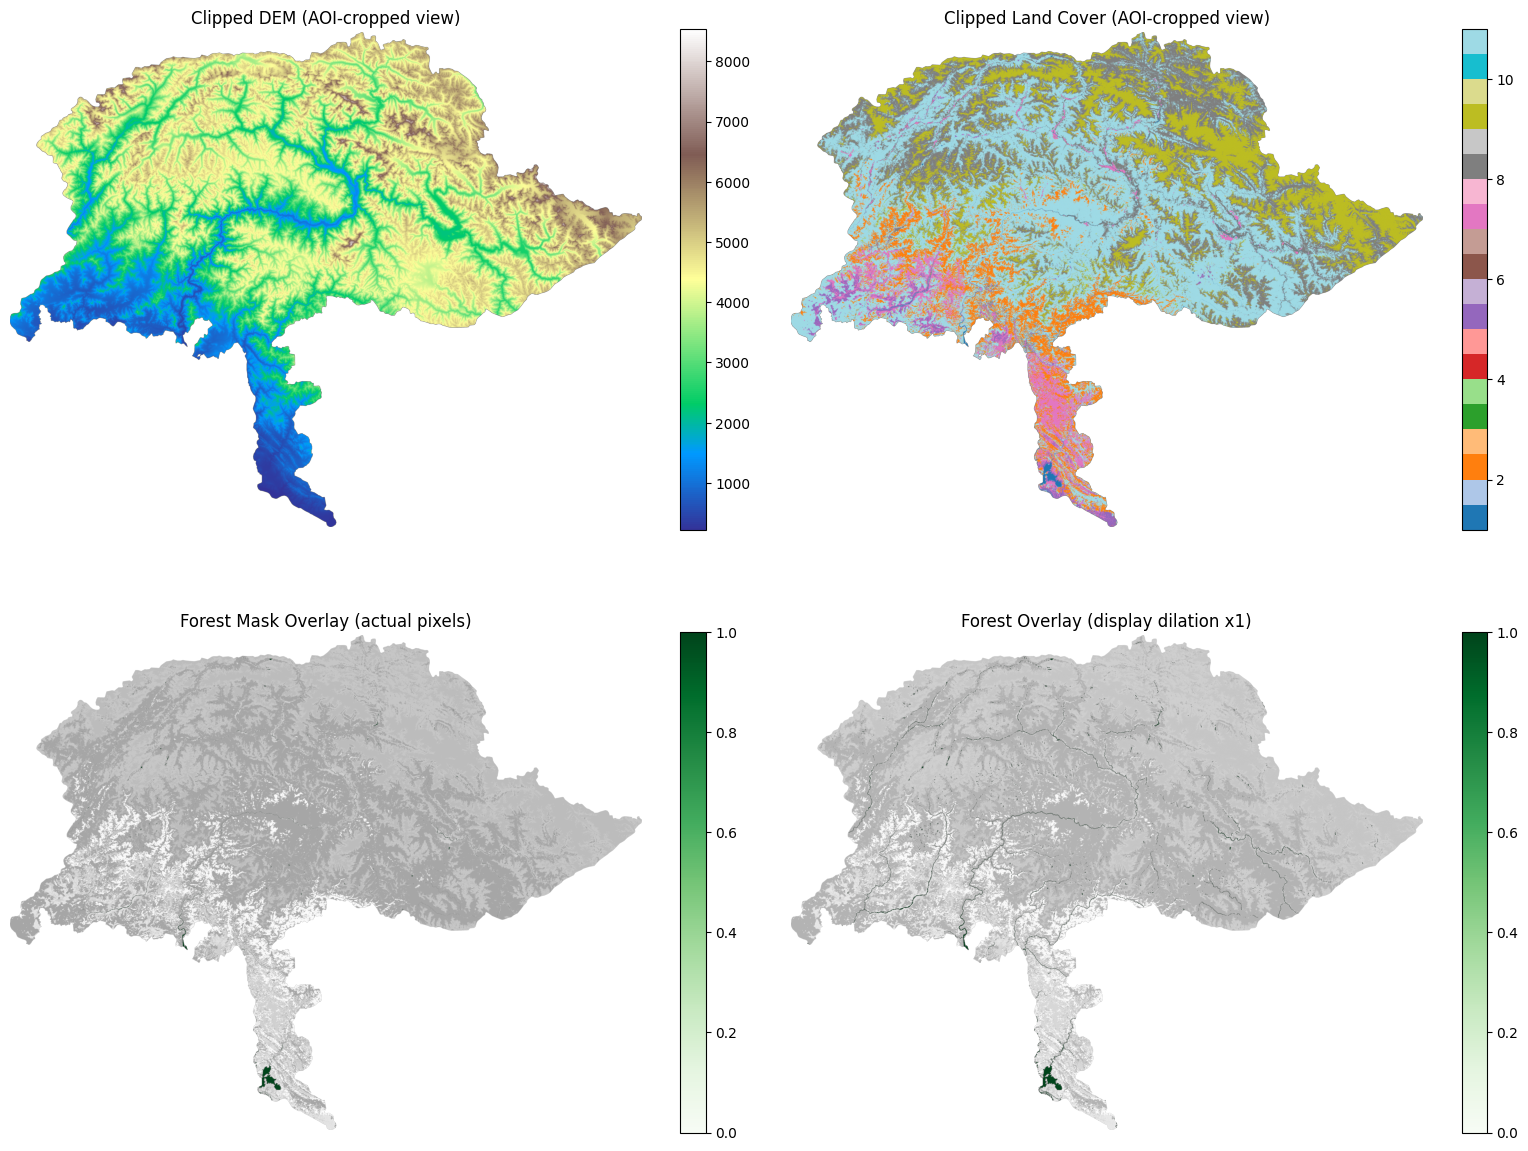

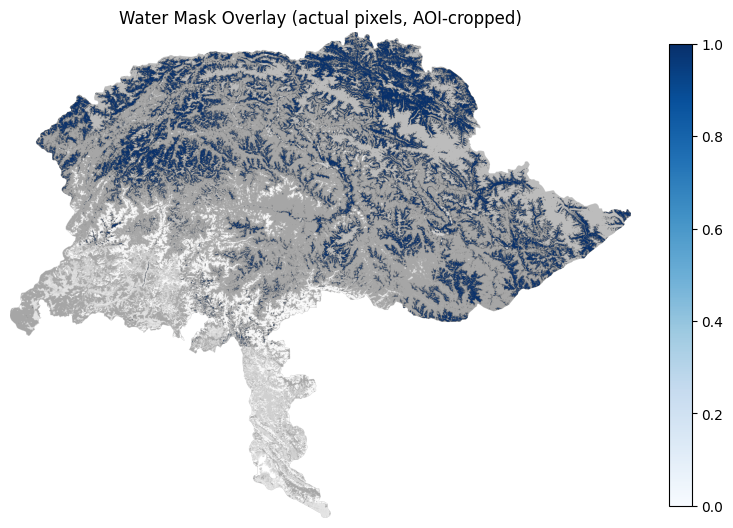

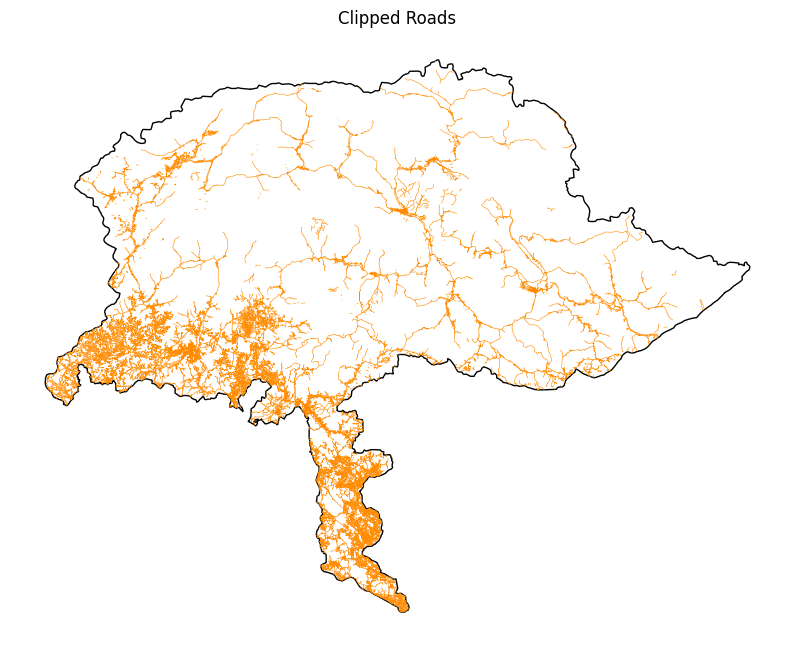

In [ ]:
import matplotlib.pyplot as plt

def read_raster(path):
    with rasterio.open(path) as src:
        return src.read(1), src.transform

def raster_extent(arr, transform):
    h, w = arr.shape
    x0 = transform.c
    x1 = x0 + w * transform.a
    y1 = transform.f
    y0 = y1 + h * transform.e
    return (x0, x1, y0, y1)

def crop_to_mask(arr, mask):
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return arr[y0:y1, x0:x1], mask[y0:y1, x0:x1], (y0, y1, x0, x1)

dem_viz, dem_tx = read_raster(interim / 'dem_32643_100m.tif')
lc_viz, lc_tx = read_raster(interim / 'landcover_2024_32643_100m.tif')
forest_viz, forest_tx = read_raster(interim / 'forest_mask_32643_100m.tif')
water_viz, water_tx = read_raster(interim / 'water_mask_32643_100m.tif')
roads_viz2 = gpd.read_file(interim / 'roads_all_32643.gpkg')

# Crop displays to AOI bbox so sparse classes are more visible.
lc_crop, mask_crop, (y0, y1, x0, x1) = crop_to_mask(lc_viz, region_mask)
dem_crop = dem_viz[y0:y1, x0:x1]
forest_crop = forest_viz[y0:y1, x0:x1]
water_crop = water_viz[y0:y1, x0:x1]

forest_overlay = np.where(forest_crop == 1, 1.0, np.nan)
water_overlay = np.where(water_crop == 1, 1.0, np.nan)

# Display-only dilation helps verify sparse forest connectivity.
forest_display = ndimage.binary_dilation(forest_crop == 1, iterations=1).astype(float)
forest_display = np.where(forest_display == 1, 1.0, np.nan)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

ax = axes[0, 0]
im = ax.imshow(np.where(mask_crop, dem_crop, np.nan), cmap='terrain')
ax.set_title('Clipped DEM (AOI-cropped view)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

ax = axes[0, 1]
im = ax.imshow(np.where(mask_crop, lc_crop, np.nan), cmap='tab20')
ax.set_title('Clipped Land Cover (AOI-cropped view)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

ax = axes[1, 0]
ax.imshow(np.where(mask_crop, lc_crop, np.nan), cmap='Greys', alpha=0.35)
im = ax.imshow(forest_overlay, cmap='Greens', vmin=0, vmax=1)
ax.set_title('Forest Mask Overlay (actual pixels)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

ax = axes[1, 1]
ax.imshow(np.where(mask_crop, lc_crop, np.nan), cmap='Greys', alpha=0.30)
im = ax.imshow(forest_display, cmap='Greens', vmin=0, vmax=1)
ax.set_title('Forest Overlay (display dilation x1)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(np.where(mask_crop, lc_crop, np.nan), cmap='Greys', alpha=0.35)
im = ax.imshow(water_overlay, cmap='Blues', vmin=0, vmax=1)
ax.set_title('Water Mask Overlay (actual pixels, AOI-cropped)')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
aoi.boundary.plot(ax=ax, color='black', lw=1.0)
if not roads_viz2.empty:
    roads_viz2.plot(ax=ax, color='darkorange', lw=0.4)
ax.set_title('Clipped Roads')
ax.set_axis_off()
plt.show()